## 3.4 양자 머신러닝 (Quantum Machine Learning)

In [ ]:
%pip install -q qiskit-machine-learning

In [1]:
# 필요한 라이브러리 불러오기
from qiskit import QuantumCircuit
from qiskit.circuit.library import RealAmplitudes
from qiskit.primitives import StatevectorSampler as Sampler  # 호환성 수정(qiskit 2.x): V1 Sampler 제거 → StatevectorSampler(V2) 사용
from qiskit_machine_learning.algorithms.classifiers import VQC
from qiskit_machine_learning.datasets import ad_hoc_data
from qiskit_aer import AerSimulator
from qiskit_algorithms.optimizers import COBYLA
import matplotlib.pyplot as plt
from qiskit.circuit import ParameterVector
import numpy as np

%matplotlib inline

##### 데이터 생성
`ad_hoc_data` 함수로 이진 분류 문제용 합성 데이터를 생성한다.

In [2]:
feature_dim = 2
training_size = 20
testing_size = 10

training_features, training_labels, testing_features, testing_labels = ad_hoc_data(
    training_size=training_size,
    test_size=testing_size,
    n=feature_dim,
    gap=0.3,
    plot_data=False
)

##### 데이터 처리

In [3]:
# 입력 데이터를 올바른 형식으로 보장
training_features = np.array(training_features)
training_labels = np.array(training_labels)
testing_features = np.array(testing_features)
testing_labels = np.array(testing_labels)

##### 특징 맵 정의
Qiskit의 `ParameterVector`로 특징 맵과 변분 회로를 정의한다.

In [4]:
# 사용자 정의 특징 맵과 변분 회로 정의
def create_feature_map(feature_dim):
    qc = QuantumCircuit(feature_dim)
    feature_params = ParameterVector('x', feature_dim)
    for i in range(feature_dim):
        qc.rx(feature_params[i], i)
    return qc

def create_var_circuit(feature_dim):
    qc = QuantumCircuit(feature_dim)
    var_params = ParameterVector('θ', feature_dim)
    for i in range(feature_dim):
        qc.ry(var_params[i], i)
    return qc

feature_map = create_feature_map(feature_dim)
var_circuit = create_var_circuit(feature_dim)

##### 옵티마이저 정의
변분 회로 학습에 `qiskit_algorithms`의 `COBYLA` 옵티마이저를 쓴다.

In [5]:
# 옵티마이저 정의
optimizer = COBYLA(maxiter=100)

##### Sampler 정의
양자 회로에서 표본을 얻기 위해 `Sampler` 프리미티브를 쓴다.

In [6]:
# Sampler 프리미티브 생성
sampler = Sampler()

##### VQC 정의

In [7]:
# VQC 정의
vqc = VQC(
    feature_map=feature_map,
    ansatz=var_circuit,
    optimizer=optimizer,
    sampler=sampler
)

No gradient function provided, creating a gradient function. If your Sampler requires transpilation, please provide a pass manager.


##### VQC 학습
특징 맵과 변분 회로를 사용해 학습 데이터로 VQC를 훈련한다.

In [8]:
# VQC 학습
vqc.fit(training_features, training_labels)

##### 예측
학습된 VQC로 테스트 데이터의 레이블을 예측한다.

In [9]:
# 예측
predicted_labels = vqc.predict(testing_features)

##### 평가
모델의 정확도를 계산한다.

In [10]:
# 평가
accuracy = vqc.score(testing_features, testing_labels)
print(f"Test Accuracy: {accuracy:.2f}")

Test Accuracy: 0.55


#### 결정 경계 시각화
VQC에 사용된 학습 데이터를 시각화한다.

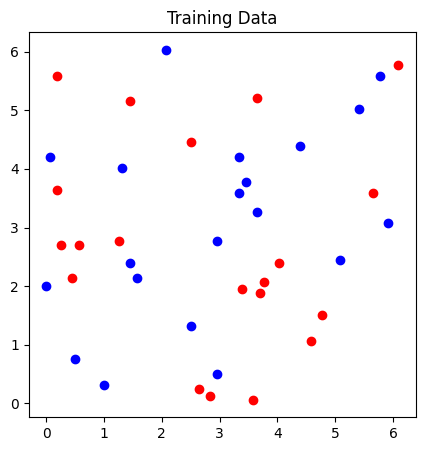

In [11]:
# 결정 경계 시각화
plt.figure(figsize=(5, 5))
for feature, label in zip(training_features, training_labels):
    # label이 배열이면 첫 원소로 스칼라화
    label = label[0] if isinstance(label, np.ndarray) else label
    color = 'r' if label == 0 else 'b'
    plt.scatter(feature[0], feature[1], c=color, marker='o')
plt.title("Training Data")
plt.show()

##### 양자 회로 시각화
VQC에 사용된 양자 회로를 시각화한다.

Feature Map Circuit:
Variational Circuit:


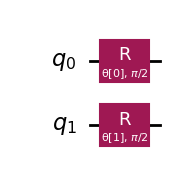

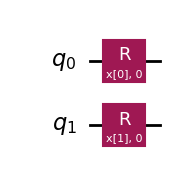

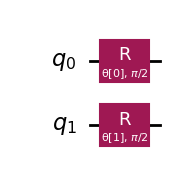

In [12]:
# 양자 회로 시각화
print("Feature Map Circuit:")
feature_map.decompose().draw('mpl')

print("Variational Circuit:")
var_circuit.decompose().draw('mpl') 